# New Customer Base Population Generator\n\nGenerates **100,000 brand-new customers** (`CustomerId` 100,001–200,000) and writes their base records directly into the live warehouse — `DimCustomer`, `FactCustomerAccount`, and `FactCustomerEngagement`. This must run **before** any of the five model notebooks (churn, CLV, fraud, lending, recommendations), since they all predict onto these new customers and their Fact tables all foreign-key against `DimCustomer.CustomerId`.\n\n**The existing 100,000 customers (IDs 1–100,000) are treated as frozen seed data** — never touched here, and used only as training ground truth by the five model notebooks.\n\n**Deliberately different from the original SQL script's generation:** the original 100k uses deterministic `CustomerId % N` formulas for everything (an exact 1/3 Retail/Corporate/SME split, exactly 500 customers per RMO). This population uses **weighted random distributions instead** — a more realistic ~70/20/10 Retail/SME/Corporate mix, and RMO/branch assignment that's randomly distributed rather than a perfect round-robin — while still only ever using valid, existing branch (1–30) and RMO (1–200) IDs, so row-level security, the admin RMO directory, and everything else already built keeps working unmodified.\n\n**Output:** the shared base feature CSV (`data/new_customers_features.csv`) that all five model notebooks read from as their prediction input, plus the live-inserted rows themselves.\n\n**Technical note:** `DimCustomer.CustomerId` is an `IDENTITY` column. Normally SQL Server would assign the next ID automatically, but we need to control the exact values ourselves so the `CIF` we generate (which embeds `CustomerId`) lines up — so this uses `SET IDENTITY_INSERT ON` for that one table (see `db_utils.bulk_insert_with_identity`).

In [1]:
import os
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from db_utils import bulk_insert, bulk_insert_with_identity, get_connection

sns.set_theme(style="whitegrid")
PURPLE = "#4a2382"
PURPLE_LIGHT = "#7c4bb8"

rng = np.random.default_rng(42)
N = 100_000
START_ID = 100_001
TODAY = datetime.today().date()

os.makedirs("data", exist_ok=True)

## 1. Generate `DimCustomer` — realistic, weighted-random distributions

In [2]:
customer_id = np.arange(START_ID, START_ID + N)

# Realistic mix - most banks skew heavily retail, unlike the seed data's exact 1/3 split
customer_type = rng.choice(["Retail", "SME", "Corporate"], size=N, p=[0.70, 0.20, 0.10])

SEGMENT_MAP = {
    "Retail": (["Mass Retail", "Premium Retail", "Youth Retail"], [0.55, 0.25, 0.20]),
    "Corporate": (["Large Corporate", "Mid Corporate", "SME Corporate"], [0.25, 0.45, 0.30]),
    "SME": (["Growth SME", "Manufacturing SME", "Service SME"], [0.40, 0.30, 0.30]),
}
segment = np.array([
    rng.choice(SEGMENT_MAP[t][0], p=SEGMENT_MAP[t][1]) for t in customer_type
])

gender = rng.choice(["Male", "Female"], size=N, p=[0.49, 0.51])
age = np.clip(rng.normal(40, 13, size=N), 18, 85).astype(int)

REGIONS = ["Lagos", "Abuja", "Port Harcourt", "Kano", "Enugu", "Kaduna", "Ibadan", "Benin"]
REGION_WEIGHTS = [0.28, 0.15, 0.12, 0.10, 0.08, 0.08, 0.10, 0.09]
region = rng.choice(REGIONS, size=N, p=REGION_WEIGHTS)

# Random (not round-robin) - but still only ever valid, existing IDs, so RLS/admin
# features keep working unmodified against a less artificially-even population.
branch_id = rng.integers(1, 31, size=N)
primary_rmo_id = rng.integers(1, 201, size=N)

created_date = [TODAY - timedelta(days=int(d)) for d in rng.integers(0, 1800, size=N)]
customer_status = rng.choice(["Active", "Dormant"], size=N, p=[0.90, 0.10])

cif_prefix = np.select(
    [customer_type == "Retail", customer_type == "Corporate", customer_type == "SME"],
    ["R", "C", "S"],
    default="R",
)
cif = [f"{p}{cid:09d}" for p, cid in zip(cif_prefix, customer_id)]
customer_name = [f"Customer {cid}" for cid in customer_id]

dim_customer = pd.DataFrame({
    "CustomerId": customer_id,
    "CIF": cif,
    "CustomerName": customer_name,
    "CustomerType": customer_type,
    "Segment": segment,
    "Gender": gender,
    "Age": age,
    "Region": region,
    "BranchId": branch_id,
    "PrimaryRmoId": primary_rmo_id,
    "CreatedDate": created_date,
    "CustomerStatus": customer_status,
})

dim_customer.head()

,CustomerId,CIF,CustomerName,CustomerType,Segment,Gender,Age,Region,BranchId,PrimaryRmoId,CreatedDate,CustomerStatus
0,100001,S000100001,Customer 100001,SME,Service SME,Male,52,Kano,26,186,2024-11-06,Active
1,100002,R000100002,Customer 100002,Retail,Youth Retail,Male,45,Kaduna,18,99,2021-12-20,Active
2,100003,S000100003,Customer 100003,SME,Manufacturing SME,Female,37,Enugu,4,109,2024-10-19,Dormant
3,100004,R000100004,Customer 100004,Retail,Mass Retail,Female,18,Abuja,17,93,2024-09-14,Active
4,100005,R000100005,Customer 100005,Retail,Premium Retail,Female,53,Enugu,27,180,2026-06-06,Active


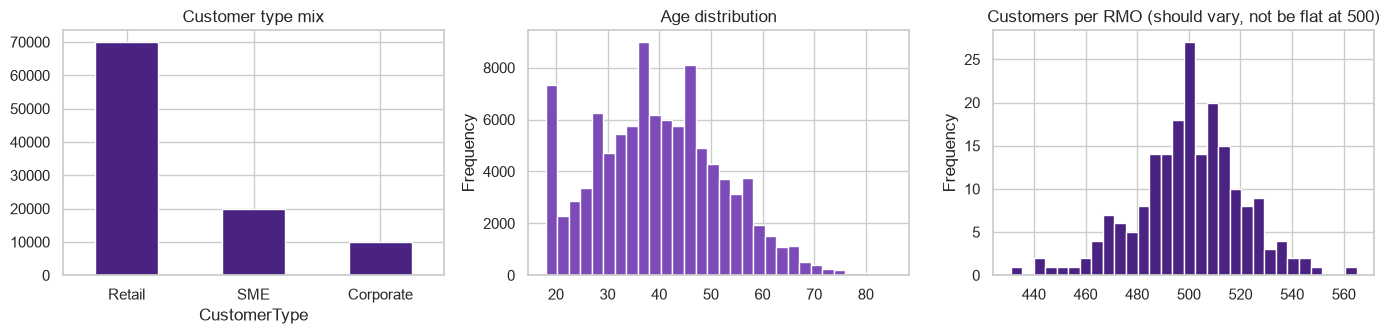

CustomerType
Retail       0.69969
SME          0.19988
Corporate    0.10043
Name: proportion, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))

dim_customer["CustomerType"].value_counts().plot(kind="bar", ax=axes[0], color=PURPLE)
axes[0].set_title("Customer type mix")
axes[0].tick_params(axis="x", rotation=0)

dim_customer["Age"].plot(kind="hist", bins=30, ax=axes[1], color=PURPLE_LIGHT)
axes[1].set_title("Age distribution")

dim_customer["PrimaryRmoId"].value_counts().plot(kind="hist", bins=30, ax=axes[2], color=PURPLE)
axes[2].set_title("Customers per RMO (should vary, not be flat at 500)")

plt.tight_layout()
plt.show()

print(dim_customer["CustomerType"].value_counts(normalize=True))

## 2. Generate `FactCustomerAccount` — one account per customer

In [4]:
ACCOUNT_TYPE_MAP = {"Corporate": "Current Account", "Retail": "Savings Account", "SME": "SME Current Account"}
PRODUCT_ID_MAP = {"Corporate": 2, "Retail": 1, "SME": 4}  # same mapping the original warehouse script uses

account_type = np.array([ACCOUNT_TYPE_MAP[t] for t in customer_type])
product_id = np.array([PRODUCT_ID_MAP[t] for t in customer_type])

# Lognormal for a realistic right-skewed balance distribution (many moderate
# balances, a smaller number of high ones) instead of the seed data's near-linear formula.
balance = np.round(np.clip(rng.lognormal(mean=11.5, sigma=0.6, size=N), 5_000, 3_000_000), 2)

account_status = np.where(customer_status == "Dormant", "Dormant", "Active")
open_date = [TODAY - timedelta(days=int(d)) for d in rng.integers(0, 1800, size=N)]
account_number = [f"ACC{cid:010d}" for cid in customer_id]

fact_account = pd.DataFrame({
    "CustomerId": customer_id,
    "AccountNumber": account_number,
    "AccountType": account_type,
    "Balance": balance,
    "AccountStatus": account_status,
    "OpenDate": open_date,
    "ProductId": product_id,
})

fact_account.head()

,CustomerId,AccountNumber,AccountType,Balance,AccountStatus,OpenDate,ProductId
0,100001,ACC0000100001,SME Current Account,95119.70,Active,2022-06-18,4
1,100002,ACC0000100002,Savings Account,124289.73,Active,2025-06-23,1
2,100003,ACC0000100003,SME Current Account,66457.86,Dormant,2023-02-16,4
3,100004,ACC0000100004,Savings Account,231909.75,Active,2024-12-03,1
4,100005,ACC0000100005,Savings Account,298066.08,Active,2025-01-09,1


## 3. Generate `FactCustomerEngagement` — no model (per decision), just plausible history

In [5]:
engagement_date = [TODAY - timedelta(days=int(d)) for d in rng.integers(0, 60, size=N)]
channel = rng.choice(["Call", "Email", "SMS"], size=N)
event_type = rng.choice(["Product Inquiry", "Retention Call", "Cross Sell"], size=N)
event_value = np.round(rng.uniform(1000, 3500, size=N), 2)
contact_outcome = rng.choice(["Converted", "Follow Up", "Engaged"], size=N)

fact_engagement = pd.DataFrame({
    "CustomerId": customer_id,
    "EngagementDate": engagement_date,
    "Channel": channel,
    "EventType": event_type,
    "EventValue": event_value,
    "ContactOutcome": contact_outcome,
})

fact_engagement.head()

,CustomerId,EngagementDate,Channel,EventType,EventValue,ContactOutcome
0,100001,2026-07-17,SMS,Product Inquiry,2077.31,Converted
1,100002,2026-06-12,Call,Retention Call,2018.20,Converted
2,100003,2026-07-03,Call,Cross Sell,1452.50,Converted
3,100004,2026-06-15,Call,Retention Call,2691.74,Follow Up
4,100005,2026-07-22,SMS,Product Inquiry,1596.80,Follow Up


## 4. Save the shared feature CSV\n\nThis is the file every model notebook reads as its prediction input — `DimCustomer` + `FactCustomerAccount` fields joined into one row per new customer.

In [6]:
features = dim_customer.merge(
    fact_account[["CustomerId", "Balance", "AccountType", "AccountStatus"]],
    on="CustomerId",
)

features_path = "data/new_customers_features.csv"
features.to_csv(features_path, index=False)
print(f"Saved {len(features):,} rows to {features_path}")
features.head()

Saved 100,000 rows to data/new_customers_features.csv


,CustomerId,CIF,CustomerName,CustomerType,Segment,Gender,Age,Region,BranchId,PrimaryRmoId,CreatedDate,CustomerStatus,Balance,AccountType,AccountStatus
0,100001,S000100001,Customer 100001,SME,Service SME,Male,52,Kano,26,186,2024-11-06,Active,95119.70,SME Current Account,Active
1,100002,R000100002,Customer 100002,Retail,Youth Retail,Male,45,Kaduna,18,99,2021-12-20,Active,124289.73,Savings Account,Active
2,100003,S000100003,Customer 100003,SME,Manufacturing SME,Female,37,Enugu,4,109,2024-10-19,Dormant,66457.86,SME Current Account,Dormant
3,100004,R000100004,Customer 100004,Retail,Mass Retail,Female,18,Abuja,17,93,2024-09-14,Active,231909.75,Savings Account,Active
4,100005,R000100005,Customer 100005,Retail,Premium Retail,Female,53,Enugu,27,180,2026-06-06,Active,298066.08,Savings Account,Active


## 5. Write directly into the live warehouse\n\nOrder matters: `DimCustomer` first (everything else foreign-keys against it), then the two facts. Uses `bulk_insert_with_identity` only for `DimCustomer` (to control the exact `CustomerId` values); the others let their own identity columns auto-assign normally.

In [7]:
conn = get_connection()

dim_cols = ["CustomerId", "CIF", "CustomerName", "CustomerType", "Segment", "Gender",
            "Age", "Region", "BranchId", "PrimaryRmoId", "CreatedDate", "CustomerStatus"]
n_dim = bulk_insert_with_identity(
    conn, "dbo.DimCustomer", dim_cols,
    list(dim_customer[dim_cols].itertuples(index=False, name=None)),
)
print(f"Inserted {n_dim:,} rows into DimCustomer")

account_cols = ["CustomerId", "AccountNumber", "AccountType", "Balance", "AccountStatus", "OpenDate", "ProductId"]
n_account = bulk_insert(
    conn, "dbo.FactCustomerAccount", account_cols,
    list(fact_account[account_cols].itertuples(index=False, name=None)),
)
print(f"Inserted {n_account:,} rows into FactCustomerAccount")

engagement_cols = ["CustomerId", "EngagementDate", "Channel", "EventType", "EventValue", "ContactOutcome"]
n_engagement = bulk_insert(
    conn, "dbo.FactCustomerEngagement", engagement_cols,
    list(fact_engagement[engagement_cols].itertuples(index=False, name=None)),
)
print(f"Inserted {n_engagement:,} rows into FactCustomerEngagement")

conn.close()

Inserted 100,000 rows into DimCustomer


Inserted 100,000 rows into FactCustomerAccount


Inserted 100,000 rows into FactCustomerEngagement


## 6. Verify — row counts and referential integrity

In [8]:
conn = get_connection()
checks = pd.read_sql(
    """
    SELECT 'Total DimCustomer' AS Check_, COUNT(*) AS Result FROM dbo.DimCustomer
    UNION ALL SELECT 'New customers (>100000)', COUNT(*) FROM dbo.DimCustomer WHERE CustomerId > 100000
    UNION ALL SELECT 'New customers with valid BranchId', COUNT(*) FROM dbo.DimCustomer c
        JOIN dbo.DimBranch b ON b.BranchId = c.BranchId WHERE c.CustomerId > 100000
    UNION ALL SELECT 'New customers with valid RMO', COUNT(*) FROM dbo.DimCustomer c
        JOIN dbo.DimRMO r ON r.RmoId = c.PrimaryRmoId WHERE c.CustomerId > 100000
    UNION ALL SELECT 'New customers with an account', COUNT(*) FROM dbo.FactCustomerAccount a
        JOIN dbo.DimCustomer c ON c.CustomerId = a.CustomerId WHERE c.CustomerId > 100000
    UNION ALL SELECT 'New customers with engagement', COUNT(*) FROM dbo.FactCustomerEngagement e
        JOIN dbo.DimCustomer c ON c.CustomerId = e.CustomerId WHERE c.CustomerId > 100000
    UNION ALL SELECT 'Duplicate CIFs (should be 0)', COUNT(*) FROM (
        SELECT CIF FROM dbo.DimCustomer GROUP BY CIF HAVING COUNT(*) > 1
    ) dupes;
    """,
    conn,
)
conn.close()
checks

/var/folders/xy/sts9z3rj3w3_957f1n6sltrm0000gn/T/ipykernel_37277/2111474333.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  checks = pd.read_sql(


,Check_,Result
0,New customers (>100000),100000
1,New customers with valid BranchId,100000
2,New customers with valid RMO,100000
3,New customers with an account,100000
4,New customers with engagement,100000
5,Total DimCustomer,200000
6,Duplicate CIFs (should be 0),0
